# Sonification of Astronomical Images

https://caltech-ipac.github.io/irsa-tutorials/siav2-seip/

https://caltech-ipac.github.io/irsa-tutorials/spherex-intro/

https://irsa.ipac.caltech.edu/data/SPHEREx/docs/overview_qr.html

https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html

This publication makes use of data products from the Spectro-Photometer for the History of the Universe, Epoch of Reionization and Ices Explorer (SPHEREx), which is a joint project of the Jet Propulsion Laboratory and the California Institute of Technology, and is funded by the National Aeronautics and Space Administration.

Hands on Astronomical Data Sonification, Adrián García Riber, SVO 2026

## Exercise: Search the SEIP Source List using IRSA Gator service (link below), find an object of interest and generate your sonification of its sky region.

https://irsa.ipac.caltech.edu/cgi-bin/Gator/nph-scan?projshort=SPITZER

### Astroquery - Coordinate search

In [1]:
from astroquery.ipac.irsa import Irsa
from astropy.coordinates import SkyCoord
from astropy import units as u

In [2]:
coord = SkyCoord('150.425933d 2.430235d', frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip')


## Astropy - Data processing and visualization

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval

In [4]:
import astropy
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS

In [5]:
science_image = spitzer_images[spitzer_images['dataproduct_subtype']
                               == 'science'][0]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord,
                      size= 5.21 * u.arcmin, wcs=WCS(hdul[0].header))

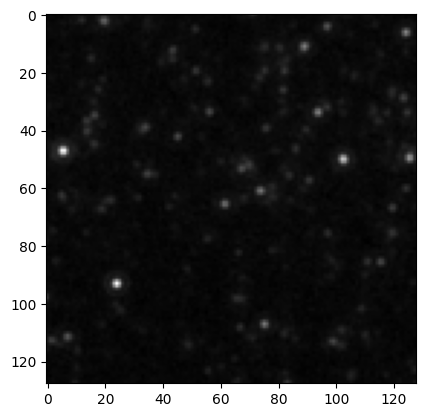

In [6]:
norm = ImageNormalize(cutout.data, interval=ZScaleInterval()) #https://docs.astropy.org/en/latest/api/astropy.visualization.mpl_normalize.ImageNormalize.html
plt.imshow(cutout.data, cmap='grey', origin='upper') # You can include the parameter: norm=norm to normalize the view
plt.savefig('image2.png')
plt.show()

#Supported colors:'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

In [7]:
len(cutout.data)

128

In [8]:
v_min = np.min(cutout.data)
v_max = np.max(cutout.data)
print (v_min, v_max)

4.1148314 5.2286215


In [9]:
np.save('Spitzer_Image_2', cutout.data)

# Sonification proposal
##### Bright <=> MIDI velocity
##### x-axis 128 pixels <=> 128 notes
##### y-axis Up-Down scanning

In [10]:
#Function for the normalization of bright levels, fits them to match the 128 values of velocity in MIDI
def normalized_brights(brights, v_min, v_max, midi_min=0, midi_max=127):
    # Normalizes to 0-1
    normalized_brights = (brights - v_min) / (v_max - v_min)
    # Scales to MIDI range
    velocity_scaled = normalized_brights * (midi_max - midi_min) + midi_min
    # Rounds and converts to integers within MIDI range
    velocity_scaled = np.clip(np.round(velocity_scaled), midi_min, midi_max).astype(int)
    return velocity_scaled


# IMPORTANT: Run this cell only if Astroquery doesn't work
Spitzer_Image = np.load('Spitzer_Image_1.npy')
brights = Spitzer_Image
v_min = np.min(brights)
v_max = np.max(brights)
normalized_brights = normalized_brights(brights, v_min, v_max)

In [11]:
# IMPORTANT: Don`t run this cell if Astroquery is not working
brights = cutout.data
normalized_brights = normalized_brights(brights, v_min, v_max)

In [12]:
dim = len(normalized_brights)
dim

128

Row: 0
Row: 1
Row: 2
Row: 3
Row: 4
Row: 5
_________Note: 124
Row: 6
_________Note: 124
Row: 7
Row: 8
Row: 9
Row: 10
_________Note: 89
Row: 11
Row: 12
Row: 13
Row: 14
Row: 15
Row: 16
Row: 17
Row: 18
Row: 19
Row: 20
Row: 21
Row: 22
Row: 23
Row: 24
Row: 25
Row: 26
Row: 27
Row: 28
Row: 29
Row: 30
Row: 31
Row: 32
_________Note: 94
Row: 33
_________Note: 93
_________Note: 94
Row: 34
Row: 35
Row: 36
Row: 37
Row: 38
Row: 39
Row: 40
Row: 41
Row: 42
Row: 43
Row: 44
Row: 45
_________Note: 5
_________Note: 6
Row: 46
_________Note: 4
_________Note: 5
_________Note: 6
_________Note: 7
Row: 47
_________Note: 5
_________Note: 6
Row: 48
_________Note: 102
_________Note: 103
_________Note: 125
_________Note: 126
Row: 49
_________Note: 102
_________Note: 103
_________Note: 125
_________Note: 126
Row: 50
_________Note: 102
_________Note: 103
Row: 51
Row: 52
Row: 53
Row: 54
Row: 55
Row: 56
Row: 57
Row: 58
Row: 59
Row: 60
_________Note: 74
Row: 61
Row: 62
Row: 63
Row: 64
Row: 65
Row: 66
Row: 67
Row: 68
Row:

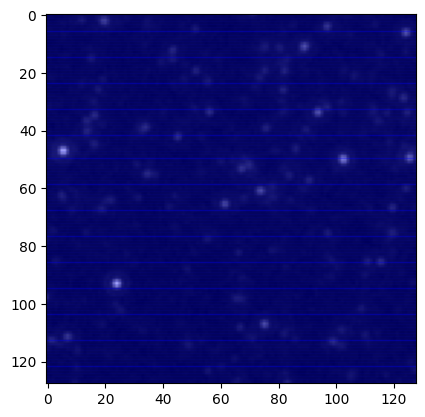

In [28]:
import time
import rtmidi
import cv2

high_threshold = 50
low_threshold = 20
speed = 0.15

chords = []
amplitudes = []

midiout = rtmidi.MidiOut()
available_ports = midiout.get_ports()

if available_ports:
    midiout.open_port(0)  # Open first available port
else:
    midiout.open_virtual_port("Virtual Output")

# Creates a single persistent window before the loop
window_name = 'SPITZER Images'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)

# Start with the image
plt.imshow(brights, cmap='grey', origin='upper')
plt.savefig('image2.png')
img = cv2.imread("image2.png")
cv2.imshow(window_name, img)
cv2.waitKey(1)

with midiout:
    
    for y in range(dim): #dim = y_dim = x_dim = 200 pixels
        #Image
        plt.axhline(y=y, color='blue', linewidth=2, alpha = 0.4)
        plt.savefig('image2.png')
        #plt.close()
        for x in range(dim):
            note = x
            amplitude = int(normalized_brights[y][x])

            if normalized_brights[y][x] >= high_threshold: #Stars and Galaxies
                #Sound
                chords.append(x)
                amplitudes.append(amplitude)
                print ("_________Note:", x)

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x90, note, amplitude]
                #note_off = [0x80, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)
                
            if low_threshold < normalized_brights[y][x] < high_threshold:    #Faint objects

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x91, note, amplitude]
                #note_off = [0x81, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)

            if  normalized_brights[y][x] < low_threshold:    #Background noise

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x92, note, amplitude]
                #note_off = [0x81, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)

        img = cv2.imread("image2.png")
        cv2.imshow(window_name, img)
                
        print ("Row:", y)
        time.sleep(speed)  
        # IMPORTANT: Process window events, small delay (1 ms)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cv2.waitKey(1)  